# Phase 3: Model 3 - Random Forest Baseline

## Objective
Establish baseline performance for accident cause code classification using a Random Forest ensemble model with a scikit-learn Pipeline. Uses the same 6 features as Logistic Regression for an apples-to-apples comparison.

## Approach
- **Model:** Random Forest Classifier (100 trees)
- **Pipeline:** OrdinalEncoder -> RandomForestClassifier (no scaling needed for trees)
- **Features:** Same 6 features as LR baseline
- **Target:** Cause_Category (E, H, M, S, T)
- **Validation:** 5-fold Stratified Cross-Validation on 80% training set
- **Evaluation:** Weighted F1-score, per-class precision/recall, confusion matrix
- **Experiments:** Baseline vs class-weighted model

**Why OrdinalEncoder instead of OneHotEncoder?** Decision trees split on threshold values (feature > X), so they naturally handle ordinal-encoded categories. OneHotEncoding would unnecessarily expand the feature space and fragment the split decisions across many binary columns.

---

## Setup

Import required libraries and set random seed for reproducibility. All random operations throughout this notebook use `RANDOM_SEED = 521` to ensure consistent results across runs.

All plots use the `tableau-colorblind10` colour cycle following CTAO best practices for colour-blind-friendly publications (CTAO, 2020). Cause categories are assigned fixed colours and hatch patterns so they can be identified through multiple visual channels.

In [29]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

# Consistent visual identity for cause categories across all plots
CAUSE_STYLES = {
    'E': {'label': 'Environmental', 'hatch': '//'},
    'H': {'label': 'Human Factor',  'hatch': '..'},
    'M': {'label': 'Mechanical',    'hatch': 'xx'},
    'S': {'label': 'Signal',        'hatch': '\\\\'},
    'T': {'label': 'Track',         'hatch': '++'},
}
CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']

## Load Training Data

Load the 80% training set from Phase 2. The 20% test set remains locked until final evaluation. Model selection and validation are handled entirely through cross-validation on this training set.

In [30]:
df_train = pd.read_csv('../data/splits/train_80.csv', low_memory=False)

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(df_train['Cause_Category'].value_counts(normalize=True).round(3))

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


## Feature Selection

Use the same 6 features as the LR baseline for a direct apples-to-apples comparison. This isolates the effect of the algorithm (LR vs RF) from the effect of the feature set.

All features are treated as categorical and encoded with OrdinalEncoder. RUCC_2023 is already numeric (1-9) but is included in the encoder for consistency. Random Forest handles ordinal encoding naturally through its threshold-based splitting mechanism.

**Note:** Accident Type is included in this baseline for comparison purposes. Phase 2 analysis identified it as a dominant confounding variable (Cramer's V = 0.39). A separate experiment will evaluate performance without it.

**Data leakage features excluded:** Cause_Name, Primary Accident Cause Code, and Accident Cause Code are never included as they directly encode the target variable.

In [31]:
# Same 6 features as LR baseline
categorical_features = [
    'Weather Condition',
    'Track Type',
    'Visibility',
    'Accident Type',
    'Region'
]

numeric_features = [
    'RUCC_2023'
]

all_features = categorical_features + numeric_features
target = 'Cause_Category'

X_train = df_train[all_features].copy()
y_train = df_train[target].copy()

print(f"Features: {len(all_features)}")
print(f"  Categorical: {categorical_features}")
print(f"  Numeric: {numeric_features}")
print(f"\nTarget classes: {sorted(y_train.unique())}")
print(f"Training samples: {len(X_train)}")

Features: 6
  Categorical: ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region']
  Numeric: ['RUCC_2023']

Target classes: ['E', 'H', 'M', 'S', 'T']
Training samples: 27640


## Build Sklearn Pipeline

The pipeline handles all preprocessing and modeling in a single object, preventing data leakage during cross-validation. Each CV fold fits the encoder only on its training portion.

**Pipeline steps:**
1. **ColumnTransformer:** OrdinalEncoder for categorical features (maps each category to an integer), passthrough for numeric features
2. **RandomForestClassifier:** 100 trees, parallel processing

**No StandardScaler** - tree-based models are invariant to feature scaling because they make decisions based on rank-order thresholds, not distance metrics.

Using `handle_unknown='use_encoded_value'` with `unknown_value=-1` in OrdinalEncoder so unseen categories in validation folds get a distinct value instead of raising errors.

In [32]:
# Preprocessing: OrdinalEncoder for categoricals, passthrough for numerics
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 
         categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Baseline pipeline: default RF
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

print("Baseline pipeline built:")
print(baseline_pipeline)

Baseline pipeline built:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Weather Condition',
                                                   'Track Type', 'Visibility',
                                                   'Accident Type', 'Region']),
                                                 ('num', 'passthrough',
                                                  ['RUCC_2023'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=521))])


## 5-Fold Stratified Cross-Validation: Baseline

Run 5-fold stratified CV on the training set. Stratification ensures each fold preserves the class distribution (particularly important for Signal at 2.5% and Environmental at 11%). The pipeline handles encoding within each fold to prevent data leakage.

We report both the per-fold scores and the mean with standard deviation. A low standard deviation indicates the model performance is stable across different data partitions.

In [33]:
# 5-fold stratified CV for baseline
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

baseline_scores = []

print("Baseline RF - 5-Fold Stratified CV")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    baseline_pipeline.fit(X_tr, y_tr)
    y_pred = baseline_pipeline.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    baseline_scores.append(f1)
    
    print(f"  Fold {fold}: Weighted F1 = {f1:.4f}")

baseline_mean = np.mean(baseline_scores)
baseline_std = np.std(baseline_scores)

print(f"\nBaseline CV: {baseline_mean:.4f} +/- {baseline_std:.4f}")

Baseline RF - 5-Fold Stratified CV
---------------------------------------------
  Fold 1: Weighted F1 = 0.5557
  Fold 2: Weighted F1 = 0.5497
  Fold 3: Weighted F1 = 0.5359
  Fold 4: Weighted F1 = 0.5517
  Fold 5: Weighted F1 = 0.5607

Baseline CV: 0.5507 +/- 0.0083


### Baseline CV Findings

Evaluate the stability of cross-validation scores. A standard deviation below 0.01 indicates highly stable performance across folds. The mean weighted F1 establishes our RF baseline benchmark for comparison against LR.

## Experiment: Class-Weighted Model

Address class imbalance by applying `class_weight='balanced'`, which automatically adjusts weights inversely proportional to class frequencies. This penalizes the model more heavily for misclassifying rare classes (Signal at 2.5%, Environmental at 11%).

The LR baseline showed that class weighting hurt overall weighted F1. We test whether the same pattern holds for Random Forest.

In [34]:
# Balanced pipeline: same preprocessing, class-weighted RF
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

balanced_scores = []

print("Balanced RF - 5-Fold Stratified CV")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    balanced_pipeline.fit(X_tr, y_tr)
    y_pred = balanced_pipeline.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    balanced_scores.append(f1)
    
    print(f"  Fold {fold}: Weighted F1 = {f1:.4f}")

balanced_mean = np.mean(balanced_scores)
balanced_std = np.std(balanced_scores)

print(f"\nBalanced CV: {balanced_mean:.4f} +/- {balanced_std:.4f}")

Balanced RF - 5-Fold Stratified CV
---------------------------------------------
  Fold 1: Weighted F1 = 0.5019
  Fold 2: Weighted F1 = 0.4949
  Fold 3: Weighted F1 = 0.5020
  Fold 4: Weighted F1 = 0.5016
  Fold 5: Weighted F1 = 0.5050

Balanced CV: 0.5011 +/- 0.0033


## Model Comparison

Compare baseline vs class-weighted RF across all 5 folds. This determines which configuration to use as the final RF model.

In [35]:
print("=" * 50)
print("MODEL COMPARISON: Baseline vs Balanced")
print("=" * 50)
print(f"  Baseline CV:  {baseline_mean:.4f} +/- {baseline_std:.4f}")
print(f"  Balanced CV:  {balanced_mean:.4f} +/- {balanced_std:.4f}")
print(f"  Difference:   {balanced_mean - baseline_mean:+.4f}")

if baseline_mean > balanced_mean:
    best_name = 'Baseline'
    best_pipeline = baseline_pipeline
    best_mean = baseline_mean
    best_std = baseline_std
else:
    best_name = 'Balanced'
    best_pipeline = balanced_pipeline
    best_mean = balanced_mean
    best_std = balanced_std

print(f"\n  Best model: {best_name} (F1 = {best_mean:.4f})")

MODEL COMPARISON: Baseline vs Balanced
  Baseline CV:  0.5507 +/- 0.0083
  Balanced CV:  0.5011 +/- 0.0033
  Difference:   -0.0497

  Best model: Baseline (F1 = 0.5507)


## Final Model: Fit on Full Training Set

Refit the best pipeline on the entire 80% training set. This is the model that will be saved and evaluated on the locked test set in the final evaluation notebook. We generate detailed metrics using the last CV fold for representative evaluation.

In [36]:
# For detailed metrics, use the last CV fold's validation predictions
last_train_idx, last_val_idx = list(skf.split(X_train, y_train))[-1]
X_eval = X_train.iloc[last_val_idx]
y_eval = y_train.iloc[last_val_idx]

best_pipeline.fit(X_train.iloc[last_train_idx], y_train.iloc[last_train_idx])
y_pred_eval = best_pipeline.predict(X_eval)

eval_f1 = f1_score(y_eval, y_pred_eval, average='weighted')

print(f"=== {best_name} Random Forest - Last Fold Evaluation ===")
print(f"Weighted F1-Score: {eval_f1:.4f}\n")
print(classification_report(y_eval, y_pred_eval, zero_division=0))

=== Baseline Random Forest - Last Fold Evaluation ===
Weighted F1-Score: 0.5607

              precision    recall  f1-score   support

           E       0.45      0.21      0.29       596
           H       0.56      0.76      0.65      2172
           M       0.79      0.56      0.65      1416
           S       0.55      0.08      0.14       139
           T       0.47      0.49      0.48      1205

    accuracy                           0.58      5528
   macro avg       0.56      0.42      0.44      5528
weighted avg       0.59      0.58      0.56      5528



## Per-Class Metrics (Secondary Metric)

Break down precision and recall by individual cause category. Compare against LR baseline to see where RF improves, particularly on rare classes (S, E) where LR struggled.

In [37]:
precision_per_class = precision_score(y_eval, y_pred_eval, average=None, 
                                     labels=CAUSE_ORDER, zero_division=0)
recall_per_class = recall_score(y_eval, y_pred_eval, average=None, 
                                labels=CAUSE_ORDER, zero_division=0)
f1_per_class = f1_score(y_eval, y_pred_eval, average=None, 
                        labels=CAUSE_ORDER, zero_division=0)

metrics_df = pd.DataFrame({
    'Cause': CAUSE_ORDER,
    'Precision': precision_per_class.round(3),
    'Recall': recall_per_class.round(3),
    'F1': f1_per_class.round(3)
})

print("=== Per-Class Metrics ===")
print(metrics_df.to_string(index=False))

=== Per-Class Metrics ===
Cause  Precision  Recall    F1
    E      0.449   0.213 0.289
    H      0.562   0.765 0.648
    M      0.787   0.557 0.652
    S      0.550   0.079 0.138
    T      0.467   0.491 0.479


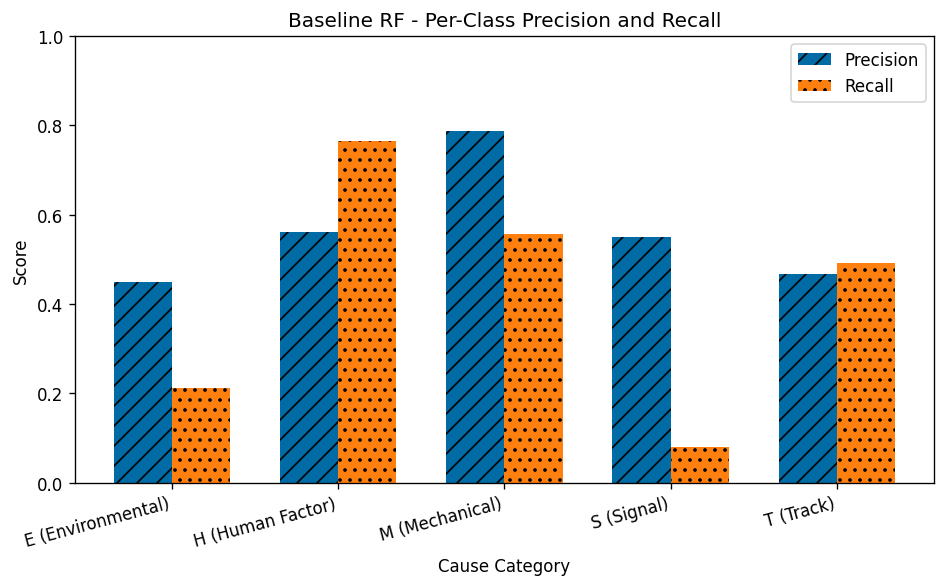

In [38]:
# Per-class precision and recall bar chart
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(CAUSE_ORDER))
width = 0.35

bars_p = ax.bar(x - width/2, metrics_df['Precision'], width, label='Precision')
bars_r = ax.bar(x + width/2, metrics_df['Recall'], width, label='Recall')

# Add hatch patterns for accessibility
for bar in bars_p:
    bar.set_hatch('//')
for bar in bars_r:
    bar.set_hatch('..')

ax.set_xlabel('Cause Category')
ax.set_ylabel('Score')
ax.set_title(f'{best_name} RF - Per-Class Precision and Recall')
ax.set_xticks(x)
ax.set_xticklabels([f"{c} ({CAUSE_STYLES[c]['label']})" for c in CAUSE_ORDER], 
                    rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## Confusion Matrix (Tertiary Metric)

Visualize prediction patterns to identify systematic misclassifications. Compare against LR's confusion matrix to see if RF reduces specific misclassification patterns.

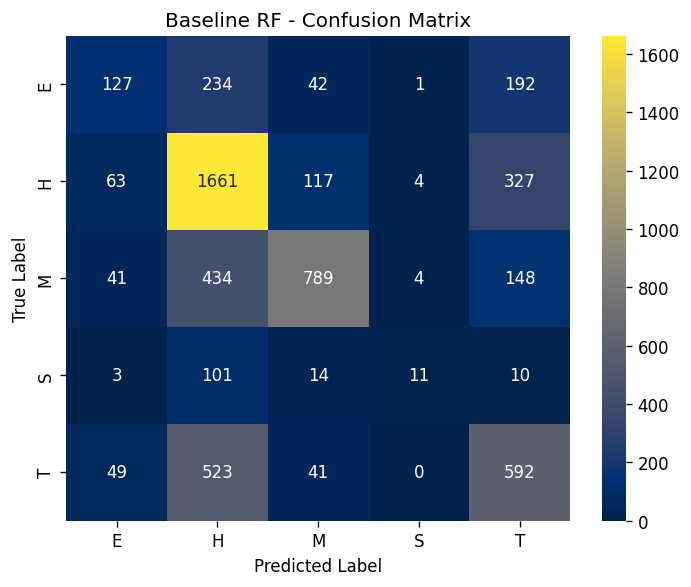

In [39]:
cm = confusion_matrix(y_eval, y_pred_eval, labels=CAUSE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
ax.set_title(f'{best_name} RF - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Cross-Validation Score Comparison

Visualize the per-fold F1 scores for both models. Horizontal dashed lines show the mean. Overlapping ranges indicate the models perform similarly; separation indicates a meaningful difference.

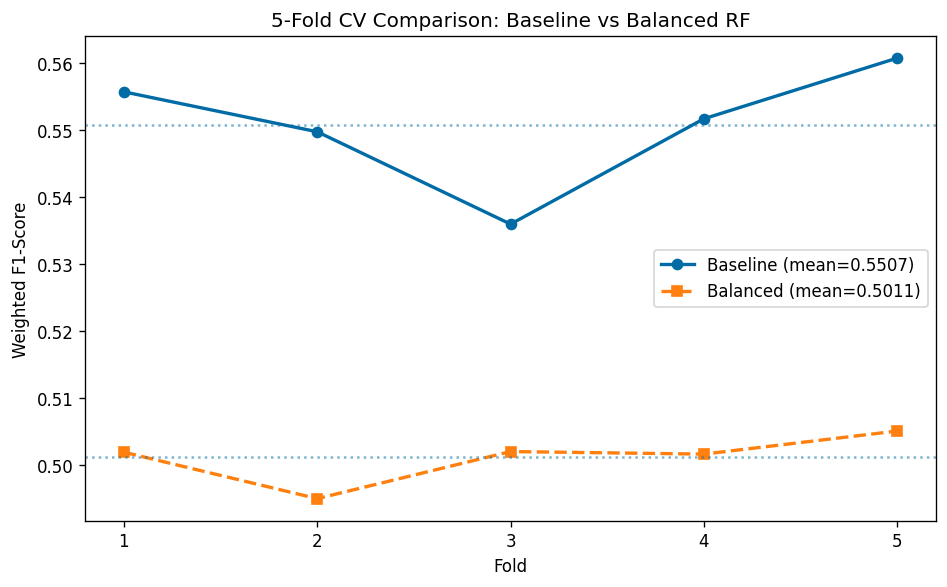

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

folds = np.arange(1, 6)

ax.plot(folds, baseline_scores, marker='o', linewidth=2, 
        label=f'Baseline (mean={baseline_mean:.4f})', linestyle='-')
ax.plot(folds, balanced_scores, marker='s', linewidth=2,
        label=f'Balanced (mean={balanced_mean:.4f})', linestyle='--')

ax.axhline(y=baseline_mean, linestyle=':', alpha=0.5)
ax.axhline(y=balanced_mean, linestyle=':', alpha=0.5)

ax.set_xlabel('Fold')
ax.set_ylabel('Weighted F1-Score')
ax.set_title('5-Fold CV Comparison: Baseline vs Balanced RF')
ax.set_xticks(folds)
ax.legend()

plt.tight_layout()
plt.show()

## Feature Importance Analysis

Extract Gini feature importance scores from the Random Forest. This shows which of the 6 features the model relies on most for split decisions. Compare against LR coefficients to see if both models agree on which features matter.

Gini importance measures how much each feature contributes to reducing impurity across all trees and splits. Higher values indicate features that produce cleaner separations between cause categories.

=== Feature Importance (Gini) ===
          Feature  Importance
    Accident Type    0.485470
       Track Type    0.153997
        RUCC_2023    0.136279
           Region    0.078630
Weather Condition    0.076374
       Visibility    0.069250


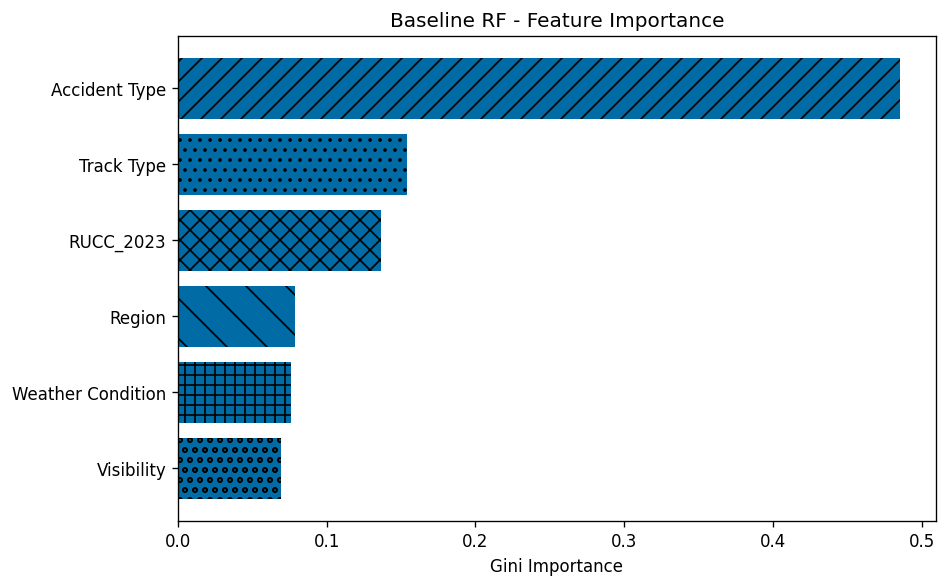

In [41]:
# Refit best pipeline on full training data for feature importance
best_pipeline.fit(X_train, y_train)

# Extract feature names after encoding
cat_encoder = best_pipeline.named_steps['preprocessor'].transformers_[0][1]
feature_names = list(categorical_features) + list(numeric_features)

importances = best_pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Feature Importance (Gini) ===")
print(importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(importance_df['Feature'], importance_df['Importance'])

# Add hatch patterns
hatches = ['//', '..', 'xx', '\\', '++', 'oo']
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.set_xlabel('Gini Importance')
ax.set_title(f'{best_name} RF - Feature Importance')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Save Model and Results

Save the best-performing pipeline and evaluation metrics for use in the final evaluation notebook. The pipeline includes all preprocessing steps (encoding) so it can be applied directly to new data without separate transformation.

In [42]:
# Pipeline is already fit on full training data from feature importance step

# Save pipeline (includes preprocessor + model)
joblib.dump(best_pipeline, '../models/rf_baseline_pipeline.pkl')
print(f"Saved: ../models/rf_baseline_pipeline.pkl")

# Save results (standardized format matching tuning experiment JSONs)
results = {
    'experiment': 'RF Baseline (with Accident Type)',
    'model': 'Random Forest',
    'features': {
        'categorical': categorical_features,
        'numeric': numeric_features,
        'total': len(categorical_features) + len(numeric_features)
    },
    'cv_folds': 5,
    'cv_scores': [float(s) for s in baseline_scores],
    'cv_mean': float(baseline_mean),
    'cv_std': float(baseline_std),
    'per_class_metrics': metrics_df.to_dict('records'),
    'feature_importance': importance_df.to_dict('records'),
    'random_seed': RANDOM_SEED,
    'balanced_cv_mean': float(balanced_mean),
    'balanced_cv_std': float(balanced_std),
    'balanced_cv_scores': [float(s) for s in balanced_scores]
}

with open('../results/rf/rf_baseline_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print(f"Saved: ../results/rf/rf_baseline_results.json")

Saved: ../models/rf_baseline_pipeline.pkl
Saved: ../results/rf/rf_baseline_results.json


## Summary

This notebook established the Random Forest baseline for cause category classification using a scikit-learn Pipeline with OrdinalEncoding and 5-fold stratified cross-validation. The same 6 features as the LR baseline were used for a direct algorithm comparison.

**Key results:**
- Baseline and balanced class-weight models were compared via CV
- Feature importance shows which of the 6 features RF relies on most
- Best model and metrics saved for final evaluation

**Design decisions:**
- OrdinalEncoder used instead of OneHotEncoder (trees split on thresholds, not distances)
- No StandardScaler (trees are scale-invariant)
- Same 6 features as LR for apples-to-apples comparison
- Data leakage features (Cause_Name, Cause Codes) excluded from the start
- Accident Type included for now - separate experiment will test without it

**Next steps:**
- Exploratory notebook: Track Type vs Signalization feature comparison
- Exploratory notebook: Feature set without Accident Type
- CBA baseline notebook
- Final evaluation notebook comparing all three models